In [1]:
import glob
import os
import pandas as pd

# 1. Path to your folder containing .xlsx files
Jan_files = glob.glob("NSW_WA_2022_fuelprice/NSW/1-4_8-12/*.xlsx")
May_files = glob.glob("NSW_WA_2022_fuelprice/NSW/5-7/*.xlsx")

# 2. Setup separate lists just like your original structure
df_list_jan = []
df_list_may = []

# 3. Read and append files for January to April
for filename in Jan_files:
    df = pd.read_excel(filename)
    df_list_jan.append(df)

# 4. Read and append files for May to August
for filename in May_files:
    df = pd.read_excel(filename)
    df_list_may.append(df)


In [2]:
# 5. Combine into separate master dataframes
combined_jan = pd.concat(df_list_jan, ignore_index=True)
combined_may = pd.concat(df_list_may, ignore_index=True)


In [3]:
# let row 2 be the header for combined_jan
combined_jan.columns = combined_jan.iloc[1]
combined_jan = combined_jan[2:].reset_index(drop=True)

#Strict Date Formatting
combined_may["PriceUpdatedDate"] = combined_may["PriceUpdatedDate"].astype(str).str.strip()

# Enforce the explicit format string so March 5th-8th don't get flipped/coerced
combined_may["PriceUpdatedDate"] = pd.to_datetime(
    combined_may["PriceUpdatedDate"], errors="coerce"
)
combined_may["Price"] = pd.to_numeric(combined_may["Price"], errors="coerce")

# Standard date formatting for combined_jan
combined_jan["PriceUpdatedDate"] = pd.to_datetime(
    combined_jan["PriceUpdatedDate"], format="%d/%m/%Y %I:%M:%S %p", errors="coerce"
)
    
combined_jan["Price"] = pd.to_numeric(combined_jan["Price"], errors="coerce")

# combine the two df
df = pd.concat([combined_jan, combined_may], ignore_index=True)

In [4]:
# --- Step 1: Define the metadata columns that contain the NaNs ---
# Replace these with the actual column names in your dataset
metadata_columns = [
    "ServiceStationName",
    "Address",
    "Suburb",
    "Postcode",
    "Brand",
]

# --- Step 2: Group by a unique key and forward-fill ---
# We group by 'ServiceStationName' to ensure a station doesn't accidentally
# bleed its metadata into a different station's empty rows.
for col in metadata_columns:
    df[col] = df.groupby("ServiceStationName")[col].ffill()

# --- Step 3: (Optional) Handle the very first row ---
# If a station's very first row somehow starts with an NaN, ffill won't find anything
# behind it. We can clean up any remaining stragglers globally if needed:
df[metadata_columns] = df[metadata_columns].ffill()

# Filter out only fueltype == 'Unleaded 91'
df_u91 = df[df['FuelCode'] == 'U91'].copy()

In [55]:
# Read the TGP data
tgp_path = 'NSW_WA_2022_fuelprice/AIP_TGP_Data_05-Jun-2026.xlsx'
tgp_df = pd.read_excel(tgp_path, sheet_name='Petrol TGP')

tgp_df.rename(columns={tgp_df.columns[0]: 'Date'}, inplace=True)
tgp_df['Date'] = pd.to_datetime(tgp_df['Date'], errors='coerce').dt.normalize()

tgp_syd_2022 = tgp_df.loc[
    (tgp_df['Date'].dt.year == 2022),
    ['Date', 'Sydney']
].copy()
tgp_syd_2022 = tgp_syd_2022.rename(columns={'Date': 'TGP_Date', 'Sydney': 'TGP_Sydney'})

# Remove any previous TGP merge artifacts so the cell is safe to rerun
merge_artifact_cols = [
    col for col in df_u91.columns
    if col == 'Date' or col == 'Sydney' or col.startswith('Date_') or col.startswith('Sydney_')
]
df_u91 = df_u91.drop(columns=merge_artifact_cols, errors='ignore').copy()

# Merge the TGP data with the filtered df_u91 on the normalized date
df_u91['TGP_Date'] = pd.to_datetime(df_u91['PriceUpdatedDate'], errors='coerce').dt.normalize()
df_u91 = df_u91.merge(tgp_syd_2022, how='left', on='TGP_Date')

# Optional cleanup if you only want the price column and not the join key
# df_u91 = df_u91.drop(columns=['TGP_Date'])

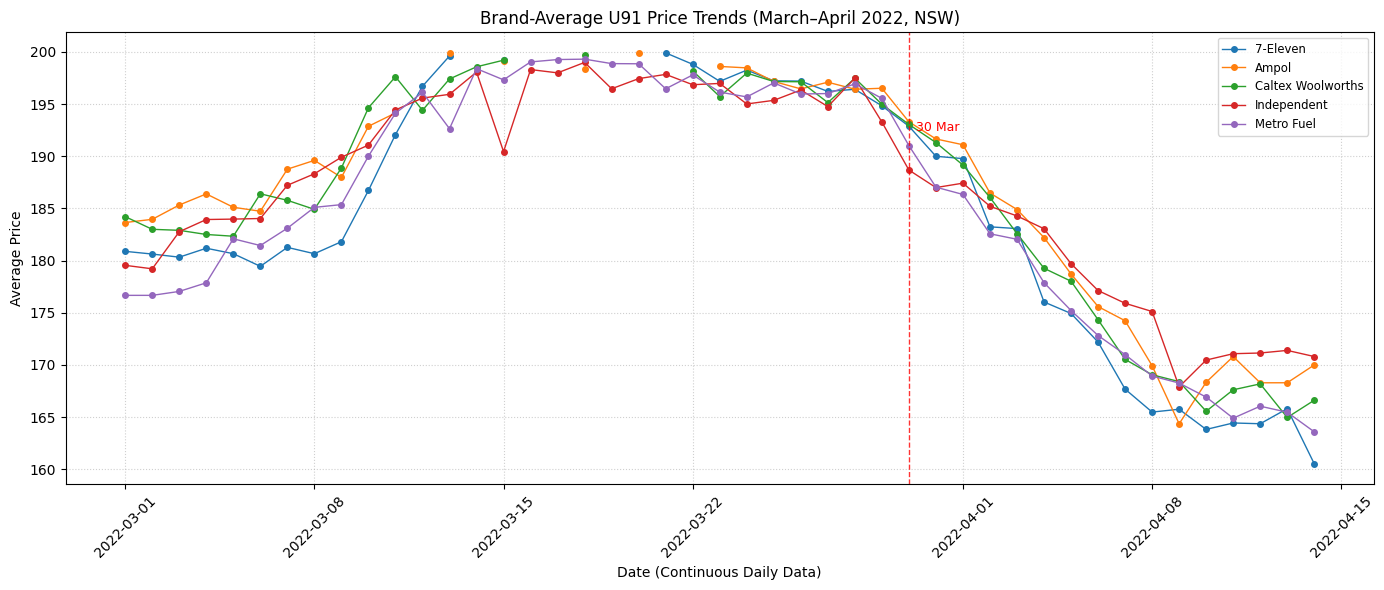

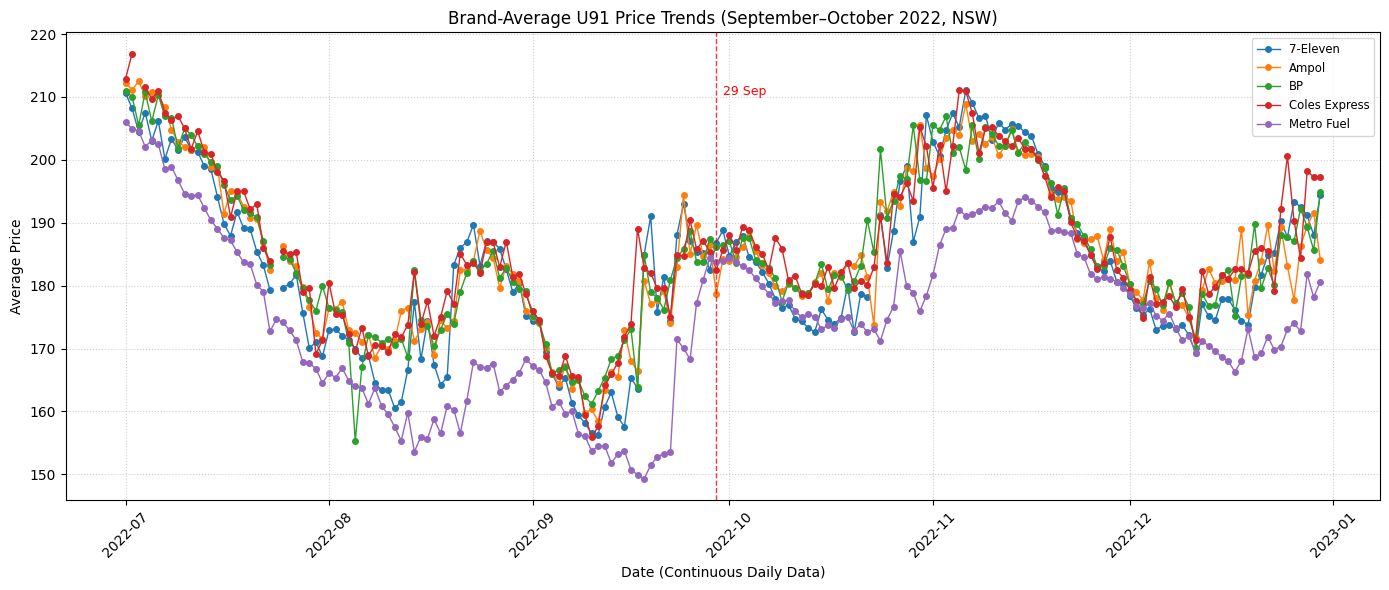

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# PLOT 1: March 23 to April 7 (With Forward-Filling for Gaps)
# =====================================================================

# 1. Prep and Filter Data
brand_plot_df = df_u91.dropna(subset=["Brand", "Price", "PriceUpdatedDate"]).copy()
brand_plot_df = brand_plot_df[
    (brand_plot_df["PriceUpdatedDate"] >= "2022-03-01")
    & (brand_plot_df["PriceUpdatedDate"] <= "2022-04-15")
] .copy()

brand_counts = brand_plot_df["Brand"].value_counts().head(5).index.tolist()
filtered_df1 = brand_plot_df[brand_plot_df["Brand"].isin(brand_counts)]

# 2. Resample and Forward-Fill per Brand
brand_trends = (
    filtered_df1.set_index("PriceUpdatedDate")
    .groupby("Brand")["Price"]
    .resample("D")
    .mean()
    .unstack("Brand")
    .sort_index()
 )

# 3. Plotting
plt.figure(figsize=(14, 6))
for brand in brand_trends.columns:
    plt.plot(
        brand_trends.index,
        brand_trends[brand],
        marker="o",
        linewidth=1,
        markersize=4,
        label=brand,
    )

plt.axvline(
    pd.Timestamp("2022-03-30"), color="red", linestyle="--", linewidth=1, alpha=0.8
)
plt.annotate(
    "30 Mar",
    xy=(pd.Timestamp("2022-03-30"), plt.gca().get_ylim()[1] * 0.95),
    xytext=(5, 5),
    textcoords="offset points",
    color="red",
    fontsize=9,
)

plt.title("Brand-Average U91 Price Trends (March–April 2022, NSW)")
plt.xlabel("Date (Continuous Daily Data)")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend(loc="best", fontsize="small")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


# =====================================================================
# PLOT 2: September 23 to October 7 (With Forward-Filling for Gaps)
# =====================================================================

# 1. Prep and Filter Data
brand_plot_sep = df_u91.dropna(subset=["Brand", "Price", "PriceUpdatedDate"]).copy()
brand_plot_sep["PriceUpdatedDate"] = pd.to_datetime(
    brand_plot_sep["PriceUpdatedDate"], errors="coerce"
)
brand_plot_sep = brand_plot_sep[
    (brand_plot_sep["PriceUpdatedDate"] >= "2022-07-01")
    & (brand_plot_sep["PriceUpdatedDate"] <= "2022-12-31")
] .copy()

sep_brand_counts = brand_plot_sep["Brand"].value_counts().head(5).index.tolist()
filtered_df2 = brand_plot_sep[brand_plot_sep["Brand"].isin(sep_brand_counts)]

# 2. Resample and Forward-Fill per Brand
sep_brand_trends = (
    filtered_df2.set_index("PriceUpdatedDate")
    .groupby("Brand")["Price"]
    .resample("D")
    .mean()
    .unstack("Brand")
    .sort_index()
 )

# 3. Plotting
plt.figure(figsize=(14, 6))
for brand in sep_brand_trends.columns:
    plt.plot(
        sep_brand_trends.index,
        sep_brand_trends[brand],
        marker="o",
        linewidth=1,
        markersize=4,
        label=brand,
    )

plt.axvline(
    pd.Timestamp("2022-09-29"), color="red", linestyle="--", linewidth=1, alpha=0.8
)
plt.annotate(
    "29 Sep",
    xy=(pd.Timestamp("2022-09-29"), plt.gca().get_ylim()[1] * 0.95),
    xytext=(5, 5),
    textcoords="offset points",
    color="red",
    fontsize=9,
)


plt.title("Brand-Average U91 Price Trends (September–October 2022, NSW)")
plt.xlabel("Date (Continuous Daily Data)")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend(loc="best", fontsize="small")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



In [57]:
# Identify station-level price restorations in df_u91
# A restoration occurs when:
# 1) price increases from the previous observation for the same station
# 2) the price is the maximum within the +/- 5 day window around the date
# 3) the increase is at least 10 cents relative to the minimum of the prior 3 days

possible_station_cols = [col for col in df_u91.columns if "station" in col.lower()]
if not possible_station_cols:
    raise KeyError(f"No station column found in df_u91. Available columns: {list(df_u91.columns)}")

station_col = "ServiceStationName" if "ServiceStationName" in df_u91.columns else possible_station_cols[0]
date_col = "PriceUpdatedDate"
price_col = "Price"

# Work on a sorted copy so the lag and rolling-window checks are station-specific
restoration_df = df_u91[[station_col, date_col, price_col]].copy()
restoration_df[date_col] = pd.to_datetime(restoration_df[date_col], errors="coerce")
restoration_df[price_col] = pd.to_numeric(restoration_df[price_col], errors="coerce")
restoration_df = restoration_df.dropna(subset=[station_col, date_col, price_col])
restoration_df = restoration_df.sort_values([station_col, date_col]).copy()

restoration_parts = []
for _, station_data in restoration_df.groupby(station_col, sort=False):
    station_data = station_data.sort_values(date_col).copy()
    station_data = station_data.set_index(date_col)
    prices = station_data[price_col]

    prev_price = prices.shift(1)
    max_in_plus_minus_5_days = prices.rolling("11D", center=True, min_periods=1).max()
    min_past_3_days = prices.rolling("3D", closed="left", min_periods=1).min()

    station_data["PriceRestoration"] = (
        prices.gt(prev_price)
        & prices.eq(max_in_plus_minus_5_days)
        & ((prices - min_past_3_days) >= 10)
    )

    restoration_parts.append(station_data.reset_index())

restoration_df = pd.concat(restoration_parts, ignore_index=True)

# Merge the restoration flag back onto df_u91 and add a station-level count
station_restoration_counts = (
    restoration_df.groupby(station_col, as_index=False)["PriceRestoration"]
    .sum()
    .rename(columns={"PriceRestoration": "NumRestorations"})
)

station_restoration_counts["NumRestorations"] = station_restoration_counts["NumRestorations"].astype(int)

# Attach the flag and count to each row in df_u91
df_u91 = df_u91.merge(
    restoration_df[[station_col, date_col, price_col, "PriceRestoration"]],
    on=[station_col, date_col, price_col],
    how="left",
)
df_u91 = df_u91.merge(station_restoration_counts, on=station_col, how="left")
df_u91["PriceRestoration"] = df_u91["PriceRestoration"].fillna(False)
df_u91["NumRestorations"] = df_u91["NumRestorations"].fillna(0).astype(int)

# Quick check: station-level restoration counts
station_restoration_counts.sort_values("NumRestorations", ascending=False).head(10)

,ServiceStationName,NumRestorations
1696,Metro Petroleum Ballina,183
1749,Metro Petroleum West Hoxton,111
1763,Metro Tuggerah,73
1659,Metro Fuel Tura Beach,66
1684,Metro North Wyong,58
1888,SPEEDWAY AUSTRAL,54
1872,Randwick Petroleum,40
1683,Metro Mt Pritchard,35
1609,Metro Bellbird Heights,25
1700,Metro Petroleum Bellbird,24


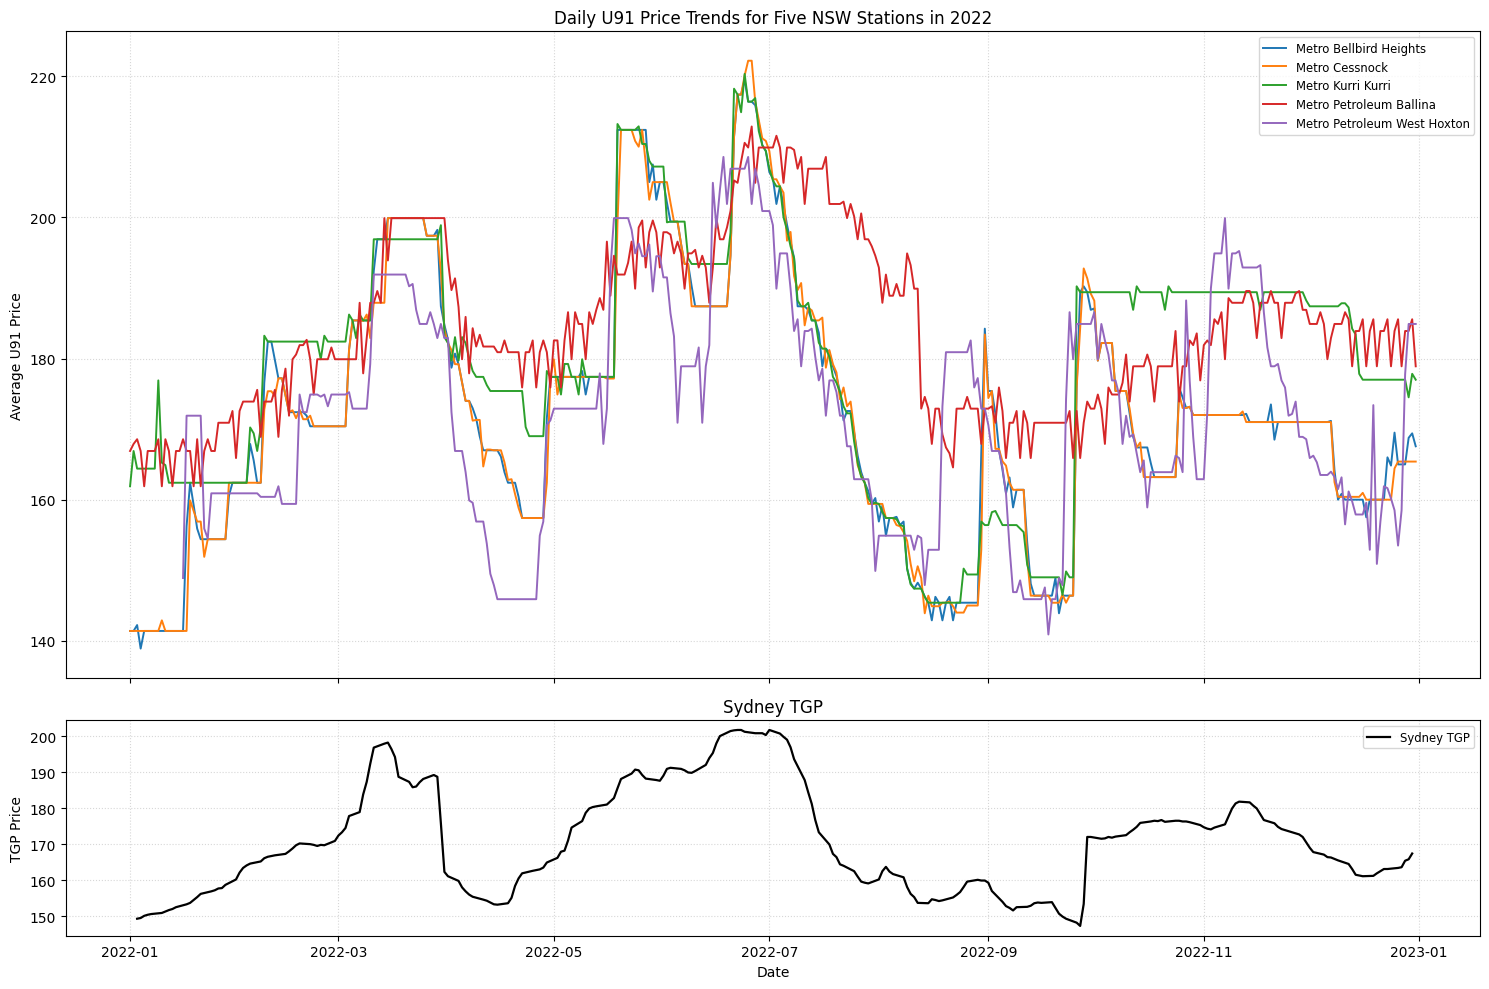

Stations plotted:
Metro Bellbird Heights
Metro Cessnock
Metro Kurri Kurri
Metro Petroleum Ballina
Metro Petroleum West Hoxton

Postcodes:
Metro Bellbird Heights: 2325
Metro Cessnock: 2325
Metro Kurri Kurri: 2327
Metro Petroleum Ballina: 2478
Metro Petroleum West Hoxton: 2171


In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Pick five stations with the most observations in 2022 so the trends are comparable
plot_df = df_u91.dropna(subset=["PriceUpdatedDate", "Price"] ).copy()
plot_df["PriceUpdatedDate"] = pd.to_datetime(plot_df["PriceUpdatedDate"], errors="coerce")
plot_df = plot_df.dropna(subset=["PriceUpdatedDate"])
plot_df = plot_df[(plot_df["PriceUpdatedDate"] >= "2022-01-01") & (plot_df["PriceUpdatedDate"] < "2023-01-01")].copy()

station_candidates = [col for col in plot_df.columns if "station" in col.lower()]
if not station_candidates:
    raise KeyError(f"No station column found in df_u91. Available columns: {list(plot_df.columns)}")

station_name_col = "ServiceStationName" if "ServiceStationName" in plot_df.columns else station_candidates[0]
top_5_stations = plot_df[station_name_col].value_counts().head(5).index.tolist()
station_plot_df = plot_df[plot_df[station_name_col].isin(top_5_stations)].copy()

# Daily average price by station, forward-filled to remove gaps in the plot
station_daily = (
    station_plot_df.set_index("PriceUpdatedDate")
    .groupby(station_name_col)["Price"]
    .resample("D")
    .mean()
    .unstack(station_name_col)
    .sort_index()
    .ffill()
)

# TGP series below the station plot
if "TGP_Date" in df_u91.columns and "TGP_Sydney" in df_u91.columns:
    tgp_series = (
        df_u91[["TGP_Date", "TGP_Sydney"]]
        .dropna(subset=["TGP_Date", "TGP_Sydney"])
        .drop_duplicates(subset=["TGP_Date"])
        .assign(TGP_Date=lambda d: pd.to_datetime(d["TGP_Date"], errors="coerce"))
        .set_index("TGP_Date")["TGP_Sydney"]
        .sort_index()
        .ffill()
    )
else:
    raise KeyError("TGP_Date and TGP_Sydney are required in df_u91 for the lower panel.")

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

for station in station_daily.columns:
    axes[0].plot(
        station_daily.index,
        station_daily[station],
        linewidth=1.4,
        label=station,
    )

axes[0].set_title("Daily U91 Price Trends for Five NSW Stations in 2022")
axes[0].set_ylabel("Average U91 Price")
axes[0].grid(True, linestyle=":", alpha=0.5)
axes[0].legend(loc="best", fontsize="small")

axes[1].plot(tgp_series.index, tgp_series.values, color="black", linewidth=1.6, label="Sydney TGP")
axes[1].set_title("Sydney TGP")
axes[1].set_ylabel("TGP Price")
axes[1].set_xlabel("Date")
axes[1].grid(True, linestyle=":", alpha=0.5)
axes[1].legend(loc="best", fontsize="small")

plt.tight_layout()
plt.show()

print("Stations plotted:")
for station in top_5_stations:
    print(station)

print("\nPostcodes:")
station_postcodes = (
    station_plot_df[[station_name_col, "Postcode"]]
    .dropna(subset=[station_name_col, "Postcode"])
    .drop_duplicates(subset=[station_name_col])
    .set_index(station_name_col)["Postcode"]
)
for station in top_5_stations:
    postcode = station_postcodes.get(station, "Unknown")
    print(f"{station}: {postcode}")

In [31]:
# Define station-level restorations and create a cycling indicator
# CyclingIndicator = 1 if a station has more than 15 restorations in the year

possible_station_cols = [col for col in df_u91.columns if "station" in col.lower()]
if not possible_station_cols:
    raise KeyError(f"No station column found in df_u91. Available columns: {list(df_u91.columns)}")

station_col = "ServiceStationName" if "ServiceStationName" in df_u91.columns else possible_station_cols[0]
date_col = "PriceUpdatedDate"
price_col = "Price"

# Remove any prior outputs so the cell can be rerun safely
artifact_cols = ["PriceRestoration", "NumRestorations", "CyclingIndicator"]
df_u91 = df_u91.drop(columns=[col for col in artifact_cols if col in df_u91.columns], errors="ignore").copy()

df_restoration = df_u91[[station_col, date_col, price_col]].copy()
df_restoration[date_col] = pd.to_datetime(df_restoration[date_col], errors="coerce")
df_restoration[price_col] = pd.to_numeric(df_restoration[price_col], errors="coerce")
df_restoration = df_restoration.dropna(subset=[station_col, date_col, price_col])
df_restoration = df_restoration.sort_values([station_col, date_col]).copy()

restoration_parts = []
for _, station_data in df_restoration.groupby(station_col, sort=False):
    station_data = station_data.sort_values(date_col).copy()
    station_data = station_data.set_index(date_col)
    prices = station_data[price_col]

    prev_price = prices.shift(1)
    max_in_plus_minus_5_days = prices.rolling("11D", center=True, min_periods=1).max()
    min_past_3_days = prices.rolling("3D", closed="left", min_periods=1).min()

    station_data["PriceRestoration"] = (
        prices.gt(prev_price)
        & prices.eq(max_in_plus_minus_5_days)
        & ((prices - min_past_3_days) >= 10)
    )

    restoration_parts.append(station_data.reset_index())

restoration_df = pd.concat(restoration_parts, ignore_index=True)

station_restoration_counts = (
    restoration_df.groupby(station_col, as_index=False)["PriceRestoration"]
    .sum()
    .rename(columns={"PriceRestoration": "NumRestorations"})
)
station_restoration_counts["NumRestorations"] = station_restoration_counts["NumRestorations"].astype(int)
station_restoration_counts["CyclingIndicator"] = (station_restoration_counts["NumRestorations"] > 15).astype(int)

# Merge indicators back to the main dataframe
df_u91 = df_u91.merge(
    restoration_df[[station_col, date_col, price_col, "PriceRestoration"]],
    on=[station_col, date_col, price_col],
    how="left",
)
df_u91 = df_u91.merge(station_restoration_counts, on=station_col, how="left")
df_u91["PriceRestoration"] = df_u91["PriceRestoration"].fillna(False)
df_u91["NumRestorations"] = df_u91["NumRestorations"].fillna(0).astype(int)
df_u91["CyclingIndicator"] = df_u91["CyclingIndicator"].fillna(0).astype(int)


In [ ]:
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import ArcGIS

# Geocode unique stations only for the postcode range 2000-2234
postcode_min = 2000
postcode_max = 2234

station_lookup_source = df_u91.copy()
station_lookup_source["Postcode"] = pd.to_numeric(station_lookup_source["Postcode"], errors="coerce")
station_lookup_source = station_lookup_source[
    station_lookup_source["Postcode"].between(postcode_min, postcode_max, inclusive="both")
].copy()

possible_station_cols = [col for col in station_lookup_source.columns if "station" in col.lower()]
if not possible_station_cols:
    raise KeyError(f"No station column found in df_u91. Available columns: {list(station_lookup_source.columns)}")

station_name_col = "ServiceStationName" if "ServiceStationName" in station_lookup_source.columns else possible_station_cols[0]
address_cols = [col for col in ["Address", "Suburb", "Postcode"] if col in station_lookup_source.columns]
if "Address" not in address_cols:
    raise KeyError(f"No address column found in df_u91. Available columns: {list(station_lookup_source.columns)}")

# Build one row per unique station within the postcode band
geocode_source_df = (
    station_lookup_source[[station_name_col, "Address", "Suburb", "Postcode"]]
    .dropna(subset=[station_name_col, "Address", "Postcode"])
    .drop_duplicates(subset=[station_name_col, "Address", "Postcode"])
    .copy()
)

# Build stable geocoding queries and cache them
geocode_source_df["GeocodeQuery"] = (
    geocode_source_df["Address"].astype(str).str.strip()
    + ", "
    + geocode_source_df["Suburb"].fillna("").astype(str).str.strip()
    + " NSW "
    + geocode_source_df["Postcode"].astype("Int64").astype(str)
    + ", Australia"
).str.replace(r"\s+,", ",", regex=True).str.replace(r",\s+,", ", ", regex=True).str.strip(" ,")

geolocator = ArcGIS(timeout=10)
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1,
    max_retries=2,
    error_wait_seconds=2,
    swallow_exceptions=True,
)

geocode_cache = {}
unique_queries = geocode_source_df["GeocodeQuery"].dropna().unique().tolist()

for query in unique_queries:
    if query not in geocode_cache:
        geocode_cache[query] = geocode(query)

station_lookup = geocode_source_df.copy()
station_lookup["Latitude"] = station_lookup["GeocodeQuery"].map(
    lambda query: geocode_cache.get(query).latitude if geocode_cache.get(query) else pd.NA
)
station_lookup["Longitude"] = station_lookup["GeocodeQuery"].map(
    lambda query: geocode_cache.get(query).longitude if geocode_cache.get(query) else pd.NA
)



In [ ]:
# Merge coordinates back to the station observations
geo_artifact_cols = ["Latitude", "Longitude", "GeocodeQuery"]
df_u91 = df_u91.drop(columns=[col for col in geo_artifact_cols if col in df_u91.columns], errors="ignore").copy()
df_u91 = df_u91.merge(
    station_lookup[[station_name_col, "Address", "Postcode", "Latitude", "Longitude"]],
    on=[station_name_col, "Address", "Postcode"],
    how="left",
)

print(f"Stations in postcode range {postcode_min}-{postcode_max}: {len(station_lookup)}")
print(f"Successfully geocoded: {int(station_lookup['Latitude'].notna().sum())}")
print(f"Failed geocodes: {int(station_lookup['Latitude'].isna().sum())}")
station_lookup[[station_name_col, "Address", "Postcode", "Latitude", "Longitude"]].head(20)

In [37]:
# Filter out stations with missing coordinates for mapping
df_u91_mapped = df_u91.dropna(subset=["Latitude", "Longitude"]).copy()

# Create a function that calculates the distance between two points using the Haversine formula
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the Earth in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Define another function to find the number of stations within 5km radius for each station
def count_stations_within_radius(df, radius_km=5):
    counts = []
    for index, row in df.iterrows():
        lat1, lon1 = row['Latitude'], row['Longitude']
        distances = haversine_distance(lat1, lon1, df['Latitude'], df['Longitude'])
        count_within_radius = (distances <= radius_km).sum() - 1  # Exclude the station itself
        counts.append(count_within_radius)
    return counts

# Apply the function to count stations within 5km radius
df_u91_mapped['StationsWithin5km'] = count_stations_within_radius(df_u91_mapped, radius_km=5)

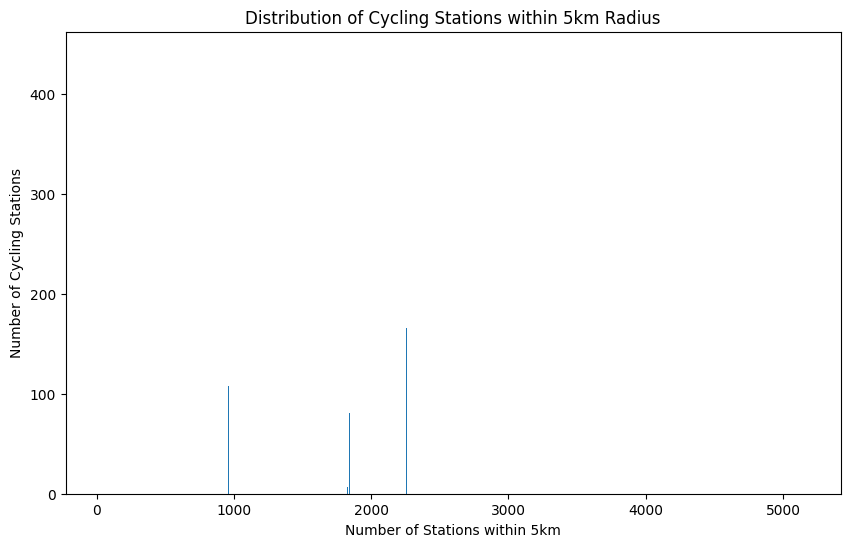

In [38]:
# Count the number of cycling staions for each number of stations within 5km radius
cycling_counts = df_u91_mapped.groupby('StationsWithin5km')['CyclingIndicator'].sum().reset_index(name='CyclingStationsCount')

# Plot Stations within 5km radius with the proportion of cycling stations
plt.figure(figsize=(10, 6))
plt.bar(cycling_counts['StationsWithin5km'], cycling_counts['CyclingStationsCount'])
plt.xlabel('Number of Stations within 5km')
plt.ylabel('Number of Cycling Stations')
plt.title('Distribution of Cycling Stations within 5km Radius')
plt.show()

In [39]:
df_u91_mapped

,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,PriceRestoration,NumRestorations,CyclingIndicator,Latitude,Longitude,StationsWithin5km
127338,Metro Fuel Old Toongabbie,"5 Picasso Cr, Old Toongabbie NSW 2146",Old Toongabbie,2146,Metro Fuel,U91,2022-07-01 01:45:04,206.9,False,9,0,-33.786362,150.967343,2076
127344,Metro Petroleum South Hurstville,"928-930 KING GEORGES RD, BLAKEHURST NSW 2221",BLAKEHURST,2221,Metro Fuel,U91,2022-07-01 05:13:58,204.9,False,23,1,-33.981085,151.108476,3165
127345,Speedway Liverpool,"406 Macquarie Street, LIVERPOOL NSW 2170",LIVERPOOL,2170,Speedway,U91,2022-07-01 05:20:06,199.9,False,4,0,-33.928153,150.919077,2340
127346,BP Berowra,"111 Berowra Waters Rd, BEROWRA HEIGHTS NSW 2082",BEROWRA HEIGHTS,2082,BP,U91,2022-07-01 05:32:49,213.9,False,6,0,-33.615586,151.141640,273
127347,Budget Bexley,"295 FOREST RD, BEXLEY NSW 2207",BEXLEY,2207,Budget,U91,2022-07-01 05:33:52,209.9,False,4,0,-33.944476,151.128349,4110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219338,Metro Petroleum South Hurstville,"928-930 KING GEORGES RD, BLAKEHURST NSW 2221",BLAKEHURST,2221,Metro Fuel,U91,2022-06-30 23:00:46,199.9,False,23,1,-33.981085,151.108476,3165
219341,Speedway Arncliffe,"32 Princes Hwy, Arncliffe NSW 2205",Arncliffe,2205,Speedway,U91,2022-06-30 23:06:14,209.9,False,3,0,-33.934571,151.152187,3289
219342,Speedway Arncliffe,"32 Princes Hwy, Arncliffe NSW 2205",Arncliffe,2205,Speedway,U91,2022-06-30 23:06:14,209.9,False,3,0,-33.934571,151.152187,3289
219345,Metro Fuel Alexandria,"36 Henderson Road, Alexandria NSW 2015",Alexandria,2015,Metro Fuel,U91,2022-06-30 23:24:47,212.9,False,1,0,-33.897447,151.197262,3013
